In [ ]:
import os
import sys
import pandas as pd
import argparse
import warnings
from utils import *
from torch import nn
import copy
from tqdm import tqdm
import random
from data_loader import *
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import numpy as np
from http import HTTPStatus
import dashscope
from dashscope import Generation
import json
# import openai
from openai import OpenAI
from deepseek import DeepSeekClient
import os
from train import *
import pickle
from together import Together
from openai import OpenAI
warnings.filterwarnings("ignore")
#set deepseek and openai API keys


DEEPSEEK_API_KEY = 'Your key'
OPENAI_API_KEY = 'Your key'
LLAMA_API_KEY='Your key'


In [2]:
parser_train = argparse.ArgumentParser()
parser_train.add_argument('--seq_len', type=int, default=24*7)
parser_train.add_argument('--pred_len', type=int, default=24)
parser_train.add_argument('--label_len', type=int, default=0)
parser_train.add_argument('--train_length', type=int, default=17376)
parser_train.add_argument('--target', type=str, default='target')
parser_train.add_argument('--scale', type=bool, default=True)
parser_train.add_argument('--inverse', type=bool, default=True)
parser_train.add_argument('--num_epochs', type=int, default=1000)
parser_train.add_argument('--mode', type=str, default='parameter')
parser_train.add_argument('--quantiles', type=list, default=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95])
parser_train.add_argument('--lr', type=float, default=1e-4)
parser_train.add_argument('--patience', type=int, default=5)
parser_train.add_argument('--hidden_layers', type=list, default=[128,128,128])
parser_train.add_argument('--e2e_num_epochs', type=int, default=5)
parser_train.add_argument('--e2e_ft_lr', type=float, default=1e-6)
parser_train.add_argument('--e2e_lr', type=float, default=1e-7)#1e-7
parser_train.add_argument('--ft_lr', type=float, default=1e-4)
parser_train.add_argument('--batch_size', type=int, default=16)
parser_train.add_argument('--device', type=str, default='cuda:0' if torch.cuda.is_available() else 'cpu')
parser_train.add_argument('--epsion_p', type=float, default=1e1)
parser_train.add_argument('--epsion_l', type=float, default=1e1)
parser_train.add_argument('--metric_list', type=list, default=['pinball_loss','winkler_score_0.1','MAE','RMSE'])


parser_train.add_argument('--N_g', type=int, default=3)
parser_train.add_argument('--T', type=int, default=24)
parser_train.add_argument('--N', type=int, default=25)
parser_train.add_argument('--x_max', type=int, default=[1500,1800,2000])
parser_train.add_argument('--x_min', type=int, default=[0,0,0])
parser_train.add_argument('--z_pos_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_neg_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_pos_min', type=int, default=0)
parser_train.add_argument('--z_neg_min', type=int, default=0)
parser_train.add_argument('--r_neg', type=int, default=[800,800,500])
parser_train.add_argument('--r_pos', type=int, default=[800,800,500])
parser_train.add_argument('--alpha', type=list, default=[0.03 for i in range(24)]+[0.028 for i in range(24)]+[0.032 for i in range(24)])
parser_train.add_argument('--alpha_pos', type=list, default=[0.02 for i in range(24)]+[0.018 for i in range(24)]+[0.022 for i in range(24)])
parser_train.add_argument('--alpha_neg', type=list, default=[0.01 for i in range(24)]+[0.009 for i in range(24)]+[0.011 for i in range(24)])

parser_train.add_argument('--rho_z_pos', type=list, default=[0.05 for i in range(24)]+[0.045 for i in range(24)]+[0.055 for i in range(24)])
parser_train.add_argument('--rho_z_neg', type=list, default=[0.01 for i in range(24)]+[0.008 for i in range(24)]+[0.012 for i in range(24)])

parser_train.add_argument('--rho_r_pos', type=list, default=[0.1 for i in range(24)])
parser_train.add_argument('--rho_r_neg', type=list, default=[0.05 for i in range(24)])

parser_train.add_argument('--price_ratio_large', type=float, default=2.5)
parser_train.add_argument('--price_ratio_small', type=float, default=0.8)
parser_train.add_argument('--flag_dynamic_price', type=bool, default=False)
parser_train.add_argument('--flag_dynamic_mode', type=int, default=0)
parser_train.add_argument('--upper_quantiles', type=float, default=0.95)
parser_train.add_argument('--lower_quantiles', type=float, default=0.05)
parser_train.add_argument('--epsion', type=float, default=1)
parser_train.add_argument('--LLM_type', type=str, default='Qwen') #'euclidean' 'manhattan'
args = parser_train.parse_args(args=[])

In [3]:
train_load_data,train_load_loader=get_load_data(args,flag='train')
val_load_data,val_load_loader=get_load_data(args,flag='val')
test_load_data,test_load_loader=get_load_data(args,flag='test')

set_seed(42)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

../../Data/GEF_data/data(3 year).csv
['month', 'weekday', 'hour', 'temp', 'load_1_day_before', 'load_2_day_before', 'load_3_day_before', 'load_4_day_before', 'load_5_day_before', 'load_6_day_before', 'load_7_day_before']
(693, 24, 11) (693, 24) (29, 24, 11) (29, 24)
(358, 24, 11)
(358, 24)
../../Data/GEF_data/data(3 year).csv
['month', 'weekday', 'hour', 'temp', 'load_1_day_before', 'load_2_day_before', 'load_3_day_before', 'load_4_day_before', 'load_5_day_before', 'load_6_day_before', 'load_7_day_before']
(693, 24, 11) (693, 24) (29, 24, 11) (29, 24)
(335, 24, 11)
(335, 24)
../../Data/GEF_data/data(3 year).csv
['month', 'weekday', 'hour', 'temp', 'load_1_day_before', 'load_2_day_before', 'load_3_day_before', 'load_4_day_before', 'load_5_day_before', 'load_6_day_before', 'load_7_day_before']
(693, 24, 11) (693, 24) (29, 24, 11) (29, 24)
(29, 24, 11)
(29, 24)


In [4]:
history_X_test = []
history_X_train = []
history_X_val = []

X_test=train_load_data.inverse_transform_X(test_load_data.X)
X_train=train_load_data.inverse_transform_X(train_load_data.X)
X_val=train_load_data.inverse_transform_X(val_load_data.X)

for i in range(len(X_test)//24):
    temp=X_test[i*24:(i+1)*24:,4:8]
    history_X_test.append(np.concatenate([temp[:, i] for i in range(temp.shape[1]-1, -1, -1)]))

for i in range(len(X_train)//24):
    temp=X_train[i*24:(i+1)*24:,4:8]
    history_X_train.append(np.concatenate([temp[:, i] for i in range(temp.shape[1]-1, -1, -1)]))

for i in range(len(X_val)//24):
    temp=X_val[i*24:(i+1)*24:,4:8]
    history_X_val.append(np.concatenate([temp[:, i] for i in range(temp.shape[1]-1, -1, -1)]))

print(np.shape(X_test))
print(np.shape(history_X_test))
print(np.shape(X_train))
print(np.shape(history_X_train))
print(np.shape(X_val))
print(np.shape(history_X_val))

(696, 11)
(29, 96)
(8592, 11)
(358, 96)
(8040, 11)
(335, 96)


In [5]:
input_size=train_load_data.X.shape[-1]
output_size=24
set_seed(42)

layer_sizes=[128,128,128]

input_size=train_load_data.X.shape[-1]
output_size=1
model_load=ANN_gaussian(input_size=input_size, hidden_layers=layer_sizes, output_size=output_size).to(device)
train_parameter(args, model_load, train_load_loader, val_load_loader,dir_best_model='../Model/best_ann_load.pt')

Epoch 0, Train Loss: 0.7720027593049136
Epoch [1/1000] Train Loss: 0.7720 Val Loss: 0.7282
Epoch [2/1000] Train Loss: 0.6608 Val Loss: 0.6028
Epoch [3/1000] Train Loss: 0.5162 Val Loss: 0.4283
Epoch [4/1000] Train Loss: 0.3167 Val Loss: 0.1953
Epoch [5/1000] Train Loss: 0.0609 Val Loss: -0.0990
Epoch [6/1000] Train Loss: -0.2893 Val Loss: -0.4934
Epoch [7/1000] Train Loss: -0.6568 Val Loss: -0.7070
Epoch [8/1000] Train Loss: -0.8241 Val Loss: -0.7556
Epoch [9/1000] Train Loss: -0.8528 Val Loss: -0.7997
Epoch [10/1000] Train Loss: -0.9192 Val Loss: -0.8057
Epoch 10, Train Loss: -0.9492454610087655
Epoch [11/1000] Train Loss: -0.9492 Val Loss: -0.8482
Epoch [12/1000] Train Loss: -0.9866 Val Loss: -0.8666
Epoch [13/1000] Train Loss: -1.0303 Val Loss: -0.8967
Epoch [14/1000] Train Loss: -1.0546 Val Loss: -0.9234
Epoch [15/1000] Train Loss: -1.0968 Val Loss: -0.9260
Epoch [16/1000] Train Loss: -1.1024 Val Loss: -0.9781
Epoch [17/1000] Train Loss: -1.1692 Val Loss: -0.9796
Epoch [18/1000] Tr

In [6]:
import numpy as np

def pinball_loss(y_true, y_pred, quantiles):
    if not isinstance(y_true, np.ndarray):
        y_true = np.array(y_true)
    
    y_true_expanded = np.expand_dims(y_true, axis=-1)
    errors = y_true_expanded - y_pred
    q_array = np.array(quantiles, dtype=y_pred.dtype)

    losses = np.maximum((q_array - 1) * errors, q_array * errors)
    loss = np.mean(losses, axis=0).sum()

    return loss

def quantile_normal_inverse_transform(mu, sigma, quantiles):
    if isinstance(mu, torch.Tensor):
        z = torch.tensor(quantiles, device=mu.device, dtype=mu.dtype)
        z_scores = torch.distributions.Normal(0, 1).icdf(z)  # shape [len(quantiles)]
        z_scores = z_scores.view(1, 1, -1)
        y_quantiles = mu.unsqueeze(-1) + sigma.unsqueeze(-1) * z_scores
    elif isinstance(mu, np.ndarray):
        z = norm.ppf(quantiles)  # shape [len(quantiles)]
        z_scores = z.reshape(1, 1, -1)
        y_quantiles = mu[:, :, np.newaxis] + sigma[:, :, np.newaxis] * z_scores
    
    return y_quantiles


In [7]:
test_input=torch.tensor(test_load_data.X).to(device).float()
test_pred_mu_nor, test_pred_var_nor = model_load(test_input)
test_pred_mu=test_load_data.scaler_y.inverse_transform(test_pred_mu_nor.detach().cpu().numpy())
test_pred_var=test_pred_var_nor.detach().cpu().numpy()*test_load_data.scaler_y.scale_
test_actual_nor=test_load_data.y
test_actual=test_load_data.scaler_y.inverse_transform(test_actual_nor)

print(MAE(test_actual, test_pred_mu),MAPE(test_actual, test_pred_mu),RMSE(test_actual, test_pred_mu))

quantiles=args.quantiles
test_quantiles=quantile_normal_inverse_transform(test_pred_mu, test_pred_var, quantiles)
print(pinball_loss(test_actual, test_quantiles, quantiles))

val_input=torch.tensor(val_load_data.X).to(device).float()
val_pred_mu_nor, val_pred_var_nor = model_load(val_input)
val_pred_mu=val_load_data.scaler_y.inverse_transform(val_pred_mu_nor.detach().cpu().numpy())
val_pred_var=val_pred_var_nor.detach().cpu().numpy()*val_load_data.scaler_y.scale_
val_actual_nor=val_load_data.y
val_actual=val_load_data.scaler_y.inverse_transform(val_actual_nor)

train_input=torch.tensor(train_load_data.X).to(device).float()
train_pred_mu_nor, train_pred_var_nor = model_load(train_input)
train_pred_mu=train_load_data.scaler_y.inverse_transform(train_pred_mu_nor.detach().cpu().numpy())
train_pred_var=train_pred_var_nor.detach().cpu().numpy()*train_load_data.scaler_y.scale_
train_actual_nor=train_load_data.y
train_actual=train_load_data.scaler_y.inverse_transform(train_actual_nor)



142.990060389727 0.04054062257193172 174.52570138295076
32601.732230395588


In [8]:
combined_train_data,combined_train_loader,combined_val_data,combined_val_loader,combined_test_data,combined_test_loader,combined_fine_tune_data,combined_fine_tune_loader = obtain_price(args,train_load_data,val_load_data,test_load_data)

data_iter = iter(combined_test_loader)
input_load_test, labels_load_test, alpha_test, alpha_z_test, rho_z_test, rho_r_test = next(data_iter)

alpha_sample=alpha_test[0,:].detach().cpu().numpy()
alpha_z_sample=alpha_z_test[0,:].detach().cpu().numpy()
rho_z_sample=rho_z_test[0,:].detach().cpu().numpy()
rho_r_sample=rho_r_test[0,:].detach().cpu().numpy()

set_seed(42)
cost_list=[]
optimization_module = Combined_SO_dispatch_GRB(args, alpha_sample, alpha_z_sample, rho_z_sample, rho_r_sample)
# solution_DA_grb, cost_DA_grb, cost_DA_grb_value=optimization_module.forward(test_pred_mu[0],test_pred_var[0],test_actual[0])
for i in range(29):
    _,_,cost=optimization_module.forward(test_pred_mu[i],test_pred_var[i],test_actual[i])
    cost_list.append(cost)
print('Average cost over 30 runs:', np.mean(cost_list))

Test data is not shuffled
Test data is not shuffled
Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-26


Average cost over 30 runs: 3028.48773274922


In [9]:
SO_layer_cvxpy = DA_dispatch_SO_cvxpy(args)
intra_dispatch_cvxpy = RT_dispatch_cvxpy(args)

model_org =  Combined_SO_dispatch_cvxpy(SO_layer_cvxpy,intra_dispatch_cvxpy, copy.deepcopy(model_load)).to(device)
model_org.to(device)

cost_list_optnet= []
for i in range(29):
    test_pred_mu_tensor=torch.tensor(test_pred_mu[i],dtype=torch.float64).unsqueeze(0).to(device)
    test_pred_var_tensor=torch.tensor(test_pred_var[i],dtype=torch.float64).unsqueeze(0).to(device)
    test_actual_tensor=torch.tensor(test_actual[i],dtype=torch.float64).unsqueeze(0).to(device)

    alpha_sample_torch=torch.tensor(alpha_sample,dtype=torch.float64).unsqueeze(0).to(device)
    alpha_z_sample_torch=torch.tensor(alpha_z_sample,dtype=torch.float64).unsqueeze(0).to(device)
    rho_z_sample_torch=torch.tensor(rho_z_sample,dtype=torch.float64).unsqueeze(0).to(device)
    rho_r_sample_torch=torch.tensor(rho_r_sample,dtype=torch.float64).unsqueeze(0).to(device)
    set_seed(42)
    solution_DA, solution_RT, cost = model_org.forward(
                        args, test_pred_mu_tensor,test_pred_var_tensor, test_actual_tensor,
                        alpha_sample_torch, alpha_z_sample_torch, rho_z_sample_torch, rho_r_sample_torch
                    )
    cost_list_optnet.append(cost.detach().cpu().numpy())
print('Average cost over 30 runs (OptNet):', np.mean(cost_list_optnet))


Average cost over 30 runs (OptNet): 3028.487733174566


In [10]:
from E2E import E2E_test_ideal,E2E_test,E2E_train

In [11]:
from E2E import E2E_test_ideal,E2E_test,E2E_train
_,_,cost_list_ideal,_,_,_=E2E_test_ideal(args, model_org, combined_test_loader, train_load_data.scaler_y)
_,_,cost_list_train_ideal,_,_,_=E2E_test_ideal(args, model_org, combined_train_loader, train_load_data.scaler_y)
_,_,cost_list_val_ideal,_,_,_=E2E_test_ideal(args, model_org, combined_val_loader, train_load_data.scaler_y)

Test Objective: 2392.189740770122
Test Objective: 2650.9600326568443
Test Objective: 2622.024603134539
Test Objective: 2452.369167679563
Test Objective: 2364.880033939213
No more data to read.
Test Objective: 2284.506774159131
Test Objective: 2247.082523717896
Test Objective: 2236.2070249696026
Test Objective: 2262.8930252153823
Test Objective: 2224.849023435543
Test Objective: 2242.131774289995
Test Objective: 2308.9750264611066
Test Objective: 2229.8297750371958
Test Objective: 2270.1205253678563
Test Objective: 2295.593524911773
Test Objective: 2264.491526149967
Test Objective: 2249.119024886811
Test Objective: 2351.0057758291214
Test Objective: 2171.1572728749243
Test Objective: 2306.5100258642424
Test Objective: 2289.2892756928554
Test Objective: 2335.115774776379
Test Objective: 2240.5287737908757
Test Objective: 2247.936270467775
Test Objective: 2287.7602780300904
Test Objective: 2251.805274657032
Test Objective: 2187.4802729311095
Test Objective: 2324.818026683723
No more data 

In [12]:

_,_, cost_list_test,forecasts_mu_test,forecasts_var_test,actual_load_test=E2E_test(args, model_org, combined_test_loader, train_load_data.scaler_y)
_,_, cost_list_val,forecasts_mu_val,forecasts_var_val,actual_load_val=E2E_test(args, model_org, combined_val_loader, train_load_data.scaler_y)
_,_, cost_list_train,forecasts_mu_train,forecasts_var_train,actual_load_train=E2E_test(args, model_org, combined_train_loader, train_load_data.scaler_y)

Test Objective: 2730.35968582262
Test Objective: 3305.7642859033117
Test Objective: 3068.0842011297345
Test Objective: 2950.1338194991868
Test Objective: 2679.8912313155965
No more data to read.
Test Objective: 2703.5863327665643
Test Objective: 2965.926567911718
Test Objective: 3048.9472337338307
Test Objective: 2806.7592325378864
Test Objective: 2507.9257192378036
Test Objective: 2851.048582467948
Test Objective: 2795.15679230802
Test Objective: 2830.9599999995753
Test Objective: 2715.8539905395646
Test Objective: 2651.811947611509
Test Objective: 2832.5235042294244
Test Objective: 2634.4148088930333
Test Objective: 2673.897786105424
Test Objective: 2908.340094538465
Test Objective: 2808.547674290036
Test Objective: 3076.4671153825407
Test Objective: 2624.9618634900326
Test Objective: 2730.389420289868
Test Objective: 2616.5212865831313
Test Objective: 2904.683253898713
Test Objective: 2535.8268927700515
No more data to read.
Test Objective: 2748.828798809909
Test Objective: 2596.182

In [13]:
model_e2e_deterministic=E2E_train(args, model_org, combined_train_loader, combined_test_loader,train_load_data.scaler_y)
_,_, cost_list_test_optnet,forecasts_mu_test_optnet,forecasts_var_test_optnet,actual_load_test_optnet=E2E_test(args, model_e2e_deterministic, combined_test_loader, train_load_data.scaler_y, time_flag=True)
_,_,cost_list_val_optnet,forecasts_mu_val_optnet,forecasts_var_val_optnet,actual_load_val_optnet=E2E_test(args, model_e2e_deterministic, combined_val_loader, train_load_data.scaler_y, time_flag=True)
_,_,cost_list_train_optnet,forecasts_mu_train_optnet,forecasts_var_train_optnet,actual_load_train_optnet=E2E_test(args, model_e2e_deterministic, combined_train_loader, train_load_data.scaler_y, time_flag=True)

e2e epoch: 0
e2e epoch: 1
e2e epoch: 2
Test Objective: 2704.250973881428
Test Objective: 3177.762683433777
Test Objective: 3061.705610649421
Test Objective: 2938.5025480871604
Test Objective: 2670.9718966554324
No more data to read.
Test Objective: 2654.4248121454657
Test Objective: 2924.225576183768
Test Objective: 3017.2229407662217
Test Objective: 2781.599785917564
Test Objective: 2517.7338321324214
Test Objective: 2806.020845850208
Test Objective: 2755.061967364659
Test Objective: 2789.2137908789446
Test Objective: 2676.5499862374772
Test Objective: 2615.6018988374717
Test Objective: 2812.7129893938054
Test Objective: 2607.2781737221503
Test Objective: 2660.6346650445057
Test Objective: 2875.194776444027
Test Objective: 2757.848757176364
Test Objective: 3028.467261039173
Test Objective: 2628.020639760345
Test Objective: 2675.212938115553
Test Objective: 2593.0172603118826
Test Objective: 2842.762088488345
Test Objective: 2528.688633452867
No more data to read.
Test Objective: 2704.

In [14]:
from model import *
from E2E import *

In [15]:
if isinstance(train_load_data.scaler_y, StandardScaler):
    scale=train_load_data.scaler_y.scale_
    mean=train_load_data.scaler_y.mean_
elif isinstance(train_load_data.scaler_y, MinMaxScaler):
    scale=train_load_data.scaler_y.data_max_-train_load_data.scaler_y.data_min_
    mean=train_load_data.scaler_y.data_min_

cost_list_test_insert=[cost_list_test[i]-cost_list_ideal[i] for i in range(len(cost_list_test))]
actual_load_test_insert=[tensor.detach().cpu().numpy() for tensor in actual_load_test]
pred_mu_test_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_mu_test]
pred_var_test_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_var_test]

cost_list_val_insert=[cost_list_val[i]-cost_list_val_ideal[i] for i in range(len(cost_list_val))]
actual_load_val_insert=[tensor.detach().cpu().numpy() for tensor in actual_load_val]
pred_mu_val_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_mu_val]
pred_var_val_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_var_val]

cost_list_train_insert=[cost_list_train[i]-cost_list_train_ideal[i] for i in range(len(cost_list_train))]
actual_load_train_insert=[tensor.detach().cpu().numpy() for tensor in actual_load_train]
pred_mu_train_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_mu_train]
pred_var_train_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_var_train]

cost_list_test_optnet_insert=[cost_list_test_optnet[i]-cost_list_ideal[i] for i in range(len(cost_list_test_optnet))]
actual_load_test_optnet_insert=[tensor.detach().cpu().numpy() for tensor in actual_load_test_optnet]
pred_mu_test_optnet_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_mu_test_optnet]
pred_var_test_optnet_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_var_test_optnet]

cost_list_val_optnet_insert=[cost_list_val_optnet[i]-cost_list_val_ideal[i] for i in range(len(cost_list_val_optnet))]
actual_load_val_optnet_insert=[tensor.detach().cpu().numpy() for tensor in actual_load_val_optnet]
pred_mu_val_optnet_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_mu_val_optnet]
pred_var_val_optnet_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_var_val_optnet]

cost_list_train_optnet_insert=[cost_list_train_optnet[i]-cost_list_train_ideal[i] for i in range(len(cost_list_train_optnet))]
actual_load_train_optnet_insert=[tensor.detach().cpu().numpy() for tensor in actual_load_train_optnet]
pred_mu_train_optnet_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_mu_train_optnet]
pred_var_train_optnet_insert=[tensor.detach().cpu().numpy() for tensor in forecasts_var_train_optnet]

history_X_insert_train=[np.concatenate([history_X_train[i], pred_mu_train_optnet_insert[i]]) for i in range(len(pred_mu_train_optnet_insert))]
history_X_insert_val=[np.concatenate([history_X_val[i], pred_mu_val_optnet_insert[i]]) for i in range(len(pred_mu_val_optnet_insert))]
history_X_insert_test=[np.concatenate([history_X_test[i], pred_mu_test_optnet_insert[i]]) for i in range(len(pred_mu_test_optnet_insert))]


db_train = CurveDictDB()
cur_id_start = max(db_train.data.keys(), default=0) + 1
for i, (cost, pred_mu,pred_var, fine_tuned_mu,fine_tuned_var, actual_load, history_X) in enumerate(zip(
                    cost_list_train_insert, 
                     pred_mu_train_insert,pred_var_train_insert, 
                     pred_mu_test_optnet_insert,pred_var_test_optnet_insert, 
                     actual_load_train_insert,history_X_insert_train)):
    record = {
        'id': cur_id_start + i,
        'flag': 0,
        'prompt': '',
        'load': pred_mu,
        'pred_var': pred_var,
        'fine_tuned_load': fine_tuned_mu,
        'fine_tuned_var': fine_tuned_var,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0, # 1代表成本比fine tune前低
        'history_X': history_X
    }
    db_train.insert(record)

db_val = CurveDictDB()
cur_id_start_val = max(db_val.data.keys(), default=0) + 1
for i, (cost, pred_mu, pred_var, fine_tuned_mu,fine_tuned_var, actual_load, history_X) in enumerate(zip(
    cost_list_val_insert, 
    pred_mu_val_insert, pred_var_val_insert,
    pred_mu_train_optnet_insert, pred_var_train_optnet_insert, 
    actual_load_val_optnet_insert, history_X_insert_val)):
    record = {
        'id': cur_id_start_val + i,
        'flag': 0,
        'prompt': '',
        'load': pred_mu,
        'pred_var': pred_var,
        'fine_tuned_load': fine_tuned_mu,
        'fine_tuned_var': fine_tuned_var,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0,
        'history_X': history_X
    }
    db_val.insert(record)


In [16]:
actual_load_test_insert[1]

array([2649.99999279, 2582.0000142 , 2568.00000297, 2585.99997596,
       2689.99999726, 2991.99996331, 3472.00001696, 3702.00009102,
       3720.00006402, 3738.00003701, 3778.00004148, 3775.99991554,
       3751.99995154, 3751.99995154, 3717.99993807, 3763.99993354,
       4027.99992436, 4184.00007719, 4140.00001425, 4012.00007731,
       3836.00001895, 3512.00002143, 3151.99998119, 2885.99996114])

In [17]:
prop_list=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
result={}
for prop in prop_list:
    result[prop]={}
    result[prop]['fine_tuned_load']=[]
    result[prop]['fine_tuned_cost']=[]
    result[prop]['org_cost']=[]
    result[prop]['org_load']=[]
    for inqure_id in range(len(pred_mu_test_insert)):
        print(f"Processing inquiry {inqure_id+1}/{len(pred_mu_test_insert)}")
        data_for_inqure = {
            'load': pred_mu_test_insert[inqure_id],
            'fine_tuned_load': pred_mu_test_optnet_insert[inqure_id],
            'pred_var': pred_var_test_insert[inqure_id],
            'fine_tuned_var': pred_var_test_optnet_insert[inqure_id],
        }


        load_numpy_mu_org = np.array(data_for_inqure['load']) # train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]
        load_numpy_var_org = np.array(data_for_inqure['pred_var']) # .reshape(1,-1)*train_load_data.scaler_y.scale_
        load_numpy_mu_optnet = np.array(data_for_inqure['fine_tuned_load']) # train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['fine_tuned_load']).reshape(1,-1))[0]
        load_numpy_var_optnet = np.array(data_for_inqure['fine_tuned_var']) # .reshape(1,-1)*train_load_data.scaler_y.scale_
        # actual_load_numpy= train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['fine_tuned_load']).reshape(1,-1))[0]
        actual_load_numpy = np.array(actual_load_test_insert[inqure_id])

        similar_days = db_train.get_top_k_unique_loads(data_for_inqure['load'], k=3, q=1)[0:3]
        average_similar_mu_org = np.mean([day['load'] for day in similar_days], axis=0)
        average_similar_var_org = np.mean([day['pred_var'] for day in similar_days], axis=0)
        average_similar_load_actual = np.mean([day['actual_load'] for day in similar_days], axis=0)
        average_similar_mu_optnet = np.mean([day['fine_tuned_load'] for day in similar_days], axis=0)
        average_similar_var_optnet = np.mean([day['fine_tuned_var'] for day in similar_days], axis=0)
        _, _, obj_org_similar_days = optimization_module.forward(average_similar_mu_org, average_similar_var_org, average_similar_load_actual)
        obj_org_similar_days = obj_org_similar_days.item()

        _, _, obj_optnet_similar_days = optimization_module.forward(average_similar_mu_optnet, average_similar_var_optnet, average_similar_load_actual)
        obj_optnet_similar_days = obj_optnet_similar_days.item()

        print('Similar days original cost:', obj_org_similar_days)#'Similar days optnet cost:', obj_optnet_similar_days)
        selected_flag = 'optnet'
        load_nor = data_for_inqure['load']
        #actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(actual_load_test_insert_optnet[inqure_id]).reshape(1,-1))[0]
        load_numpy_org = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]
        load_numpy_optnet = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['fine_tuned_load']).reshape(1,-1))[0]

        errors = average_similar_mu_org - average_similar_load_actual
        
        #fine_tuned_load_nor = train_load_data.scaler_y.transform(np.array(data_for_inqure['fine_tuned_load']).reshape(-1,1)).flatten()
        selected_curve = data_for_inqure['load'] - errors * prop

        #fine_tuned_load_numpy =  train_load_data.scaler_y.inverse_transform(np.array(selected_curve).reshape(1, -1))[0]

        _, _, obj_org = optimization_module.forward(load_numpy_mu_org, load_numpy_var_org, actual_load_numpy)
        _, _, obj_optnet = optimization_module.forward(load_numpy_mu_optnet, load_numpy_var_optnet, actual_load_numpy)
       
        # print(selected_curve)
        # print(data_for_inqure['fine_tuned_var'])
        # print(actual_load_numpy)

        _, _, obj_fine_tune = optimization_module.forward(selected_curve, data_for_inqure['pred_var'], actual_load_numpy)

        result[prop]['fine_tuned_cost'].append(obj_fine_tune)
        result[prop]['fine_tuned_load'].append(selected_curve)
        result[prop]['org_cost'].append(obj_org)
        result[prop]['org_load'].append(data_for_inqure['load'])

Processing inquiry 1/29


Similar days original cost: 2502.7238067415155
Processing inquiry 2/29
Similar days original cost: 2569.2628320699578
Processing inquiry 3/29
Similar days original cost: 2547.1003275606045
Processing inquiry 4/29
Similar days original cost: 2783.155811124138
Processing inquiry 5/29
Similar days original cost: 2996.7316348853124
Processing inquiry 6/29
Similar days original cost: 2547.1003275606045
Processing inquiry 7/29
Similar days original cost: 2600.2570532190402
Processing inquiry 8/29
Similar days original cost: 2996.7316348853124
Processing inquiry 9/29
Similar days original cost: 2622.7644136088757
Processing inquiry 10/29
Similar days original cost: 2677.470565737108
Processing inquiry 11/29
Similar days original cost: 2677.470565737108
Processing inquiry 12/29
Similar days original cost: 2677.470565737108
Processing inquiry 13/29
Similar days original cost: 2677.470565737108
Processing inquiry 14/29
Similar days original cost: 2677.470565737108
Processing inquiry 15/29
Simila

In [18]:
prop_list=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
result_optnet={}
for prop in prop_list:
    result_optnet[prop]={}
    result_optnet[prop]['fine_tuned_load']=[]
    result_optnet[prop]['fine_tuned_cost']=[]
    result_optnet[prop]['org_cost']=[]
    result_optnet[prop]['org_load']=[]
    for inqure_id in range(len(pred_mu_test_insert)):
        print(f"Processing inquiry {inqure_id+1}/{len(pred_mu_test_insert)}")
        data_for_inqure = {
            'load': pred_mu_test_insert[inqure_id],
            'fine_tuned_load': pred_mu_test_optnet_insert[inqure_id],
            'pred_var': pred_var_test_insert[inqure_id],
            'fine_tuned_var': pred_var_test_optnet_insert[inqure_id],
        }


        load_numpy_mu_org = np.array(data_for_inqure['load']) # train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]
        load_numpy_var_org = np.array(data_for_inqure['pred_var']) # .reshape(1,-1)*train_load_data.scaler_y.scale_
        load_numpy_mu_optnet = np.array(data_for_inqure['fine_tuned_load']) # train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['fine_tuned_load']).reshape(1,-1))[0]
        load_numpy_var_optnet = np.array(data_for_inqure['fine_tuned_var']) # .reshape(1,-1)*train_load_data.scaler_y.scale_
        # actual_load_numpy= train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['fine_tuned_load']).reshape(1,-1))[0]
        actual_load_numpy = np.array(actual_load_test_insert[inqure_id])

        similar_days = db_train.get_top_k_unique_loads(data_for_inqure['load'], k=3, q=1)[0:3]
        average_similar_mu_org = np.mean([day['load'] for day in similar_days], axis=0)
        average_similar_var_org = np.mean([day['pred_var'] for day in similar_days], axis=0)
        average_similar_load_actual = np.mean([day['actual_load'] for day in similar_days], axis=0)
        average_similar_mu_optnet = np.mean([day['fine_tuned_load'] for day in similar_days], axis=0)
        average_similar_var_optnet = np.mean([day['fine_tuned_var'] for day in similar_days], axis=0)
        _, _, obj_org_similar_days = optimization_module.forward(average_similar_mu_org, average_similar_var_org, average_similar_load_actual)
        obj_org_similar_days = obj_org_similar_days.item()

        _, _, obj_optnet_similar_days = optimization_module.forward(average_similar_mu_optnet, average_similar_var_optnet, average_similar_load_actual)
        obj_optnet_similar_days = obj_optnet_similar_days.item()

        print('Similar days original cost:', obj_org_similar_days)#'Similar days optnet cost:', obj_optnet_similar_days)
        selected_flag = 'optnet'
        load_nor = data_for_inqure['load']
        #actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(actual_load_test_insert_optnet[inqure_id]).reshape(1,-1))[0]
        load_numpy_org = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]
        load_numpy_optnet = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['fine_tuned_load']).reshape(1,-1))[0]

        errors = average_similar_mu_org - average_similar_load_actual
        
        #fine_tuned_load_nor = train_load_data.scaler_y.transform(np.array(data_for_inqure['fine_tuned_load']).reshape(-1,1)).flatten()
        selected_curve = data_for_inqure['fine_tuned_load'] - errors * prop

        #fine_tuned_load_numpy =  train_load_data.scaler_y.inverse_transform(np.array(selected_curve).reshape(1, -1))[0]

        _, _, obj_org = optimization_module.forward(load_numpy_mu_org, load_numpy_var_org, actual_load_numpy)
        _, _, obj_optnet = optimization_module.forward(load_numpy_mu_optnet, load_numpy_var_optnet, actual_load_numpy)
       
        # print(selected_curve)
        # print(data_for_inqure['fine_tuned_var'])
        # print(actual_load_numpy)

        _, _, obj_fine_tune = optimization_module.forward(selected_curve, data_for_inqure['fine_tuned_var'], actual_load_numpy)

        result_optnet[prop]['fine_tuned_cost'].append(obj_fine_tune)
        result_optnet[prop]['fine_tuned_load'].append(selected_curve)
        result_optnet[prop]['org_cost'].append(obj_org)
        result_optnet[prop]['org_load'].append(data_for_inqure['load'])

Processing inquiry 1/29


Similar days original cost: 2502.7238067415155
Processing inquiry 2/29
Similar days original cost: 2569.2628320699578
Processing inquiry 3/29
Similar days original cost: 2547.1003275606045
Processing inquiry 4/29
Similar days original cost: 2783.155811124138
Processing inquiry 5/29
Similar days original cost: 2996.7316348853124
Processing inquiry 6/29
Similar days original cost: 2547.1003275606045
Processing inquiry 7/29
Similar days original cost: 2600.2570532190402
Processing inquiry 8/29
Similar days original cost: 2996.7316348853124
Processing inquiry 9/29
Similar days original cost: 2622.7644136088757
Processing inquiry 10/29
Similar days original cost: 2677.470565737108
Processing inquiry 11/29
Similar days original cost: 2677.470565737108
Processing inquiry 12/29
Similar days original cost: 2677.470565737108
Processing inquiry 13/29
Similar days original cost: 2677.470565737108
Processing inquiry 14/29
Similar days original cost: 2677.470565737108
Processing inquiry 15/29
Simila

In [19]:
fine_tuned_cost_lst=[]
for prop in prop_list:
    fine_tuned_cost_lst.append(np.mean(result[prop]['fine_tuned_cost']))

fine_tuned_cost_optnet_lst=[]
for prop in prop_list:
    fine_tuned_cost_optnet_lst.append(np.mean(result_optnet[prop]['fine_tuned_cost']))

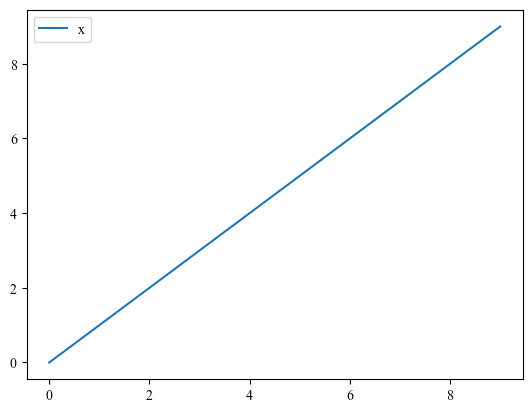

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
from matplotlib import font_manager as fm

font_path = '../../times.ttf' # 或绝对路径 '/home/me/fonts/times.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

mpl.rcParams['font.family'] = font_name
plt.plot(range(10),range(10),label='x')
plt.legend()

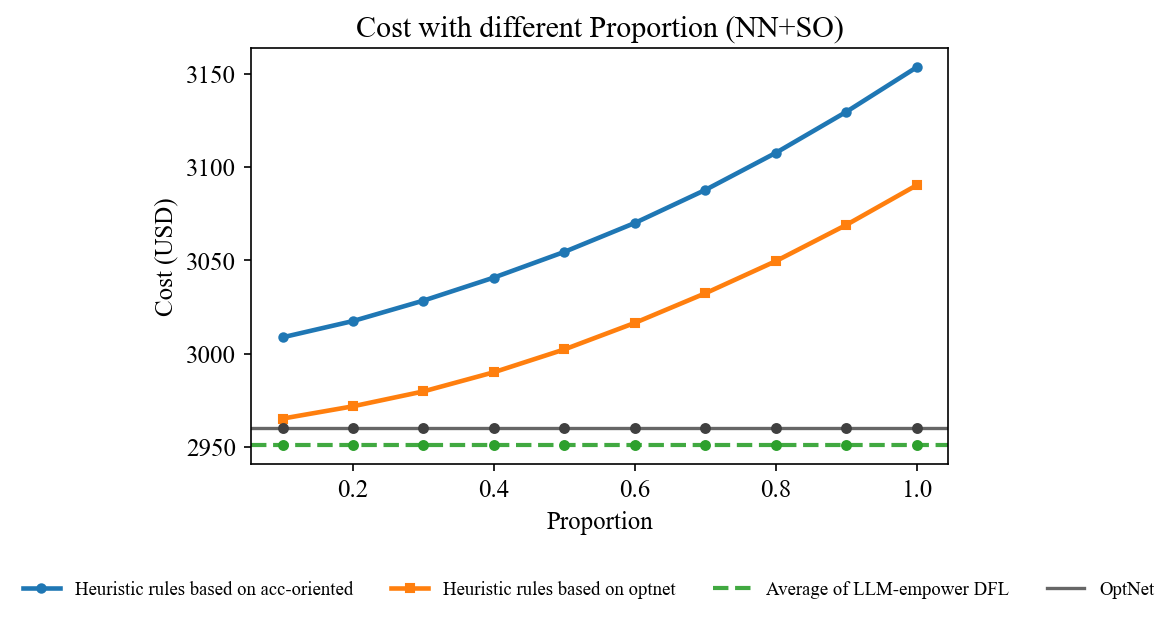

In [21]:
plt.rcParams['font.size'] = 12 
x = np.asarray(prop_list, dtype=float)
y_ft = np.asarray(fine_tuned_cost_lst, dtype=float)
y_ft_optnet = np.asarray(fine_tuned_cost_optnet_lst, dtype=float)

ds, qwen, llama = 2952.20, 2948.45, 2951.87
optnet = 2960.22
baseline_avg = (ds + qwen + llama) / 3.0

fig, ax = plt.subplots(figsize=(6, 4.2), dpi=150)

ax.plot(x, y_ft, lw=2.2, marker="o", ms=4, color="#1f77b4", label="Heuristic rules based on acc-oriented")
ax.plot(x, y_ft_optnet, lw=2.2, marker="s", ms=4, color="#ff7f0e", label="Heuristic rules based on optnet")

ax.axhline(baseline_avg, ls="--", lw=2.0, color="#2ca02c", alpha=0.9,
           label=f"Average of LLM-empower DFL")
ax.axhline(optnet, ls="-", lw=1.6, color="0.25", alpha=0.8,
           label=f"OptNet")

# 如果你想在水平线上也显示一些点，用 scatter（可选）
k = max(1, len(x)//8)
xm = x[::k]
ax.scatter(xm, np.full_like(xm, baseline_avg), s=18, color="#2ca02c", zorder=3)
ax.scatter(xm, np.full_like(xm, optnet), s=18, color="0.25", zorder=3)

ax.set_xlabel("Proportion")
ax.set_ylabel("Cost (USD)")
ax.set_title("Cost with different Proportion (NN+SO)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.22)
plt.savefig('../../Figure/Heuristic_NN_SO.jpg',dpi=1000)
plt.show()

In [27]:
with open('../../Result EN copy/NN+SO/Qwen.pkl', 'rb') as f:
    result_qwen=pickle.load(f)
#result_qwen['cost_ideal']=cost_list_ideal

with open('../../Result EN copy/NN+SO/Llama.pkl', 'rb') as f:
    result_llama=pickle.load(f)
#result_llama['cost_ideal']=cost_list_ideal

with open('../../Result EN copy/NN+SO/Deepseek.pkl', 'rb') as f:
    result_ds=pickle.load(f)
#result_ds['cost_ideal']=cost_list_ideal

# with open('../../Result EN copy/Tree+LP/Deepseek.pkl', 'wb') as f:
#     pickle.dump(result_ds, f)

# with open('../../Result EN copy/Tree+LP/Llama.pkl', 'wb') as f:
#     pickle.dump(result_llama, f)

# with open('../../Result EN copy/Tree+LP/Qwen.pkl', 'wb') as f:
#     pickle.dump(result_qwen, f)


In [28]:
result_qwen.keys()

dict_keys(['selected_flag', 'actual_load', 'original_mu', 'optnet_mu', 'fine_tuned_mu', 'original_var', 'optnet_var', 'fine_tuned_var', 'cost_after', 'cost_org', 'cost_optnet', 'similar_mu', 'similar_var', 'similar_actual_load', 'few_shot_costs', 'few_shot_curves', 'few_shot_code', 'strategy_code', 'cost_ideal'])